In [1]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd

# Ruta del archivo ROOT
file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

# Abrir el archivo
root_file = uproot.open(file_path)

# Mostrar los árboles que contiene
print("Árboles y claves en el ROOT file:")
for key in root_file.keys():
    print(key)


Árboles y claves en el ROOT file:
peak;31
spectrum;8
temp;3


In [2]:
import uproot

file_path = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
root_file = uproot.open(file_path)

# Árboles principales
trees = ["peak", "spectrum", "temp"]

for tree_name in trees:
    tree = root_file[tree_name]
    print(f"Ramas en el árbol '{tree_name}':")
    print(tree.keys())
    print("-"*40)


Ramas en el árbol 'peak':
['t', 'wav', 'sweep', 'ch', 'pos']
----------------------------------------
Ramas en el árbol 'spectrum':
['t', 'wav']
----------------------------------------
Ramas en el árbol 'temp':
['t', 'temp']
----------------------------------------


In [3]:
import uproot
import numpy as np

# Archivo ROOT de entrada
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

# Abrir el archivo ROOT con uproot
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    spectrum_tree = file["spectrum"]
    temp_tree = file["temp"]
    
    # Cargar ramas como numpy arrays
    peak_data = peak_tree.arrays(library="np")
    spectrum_data = spectrum_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Imprimir shapes de todas las variables ---
print("=== peak ===")
for key, value in peak_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== spectrum ===")
for key, value in spectrum_data.items():
    print(f"{key}: {np.array(value).shape}")

print("\n=== temp ===")
for key, value in temp_data.items():
    print(f"{key}: {np.array(value).shape}")



=== peak ===
t: (8570400, 2)
wav: (8570400, 2, 5)
sweep: (8570400, 2, 5)
ch: (8570400, 5)
pos: (8570400, 5)

=== spectrum ===
t: (1083, 2)
wav: (1083, 2, 3, 39200)

=== temp ===
t: (43683,)
temp: (43683, 6)


/tmp/ipykernel_452/3289714055.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_452/3289714055.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


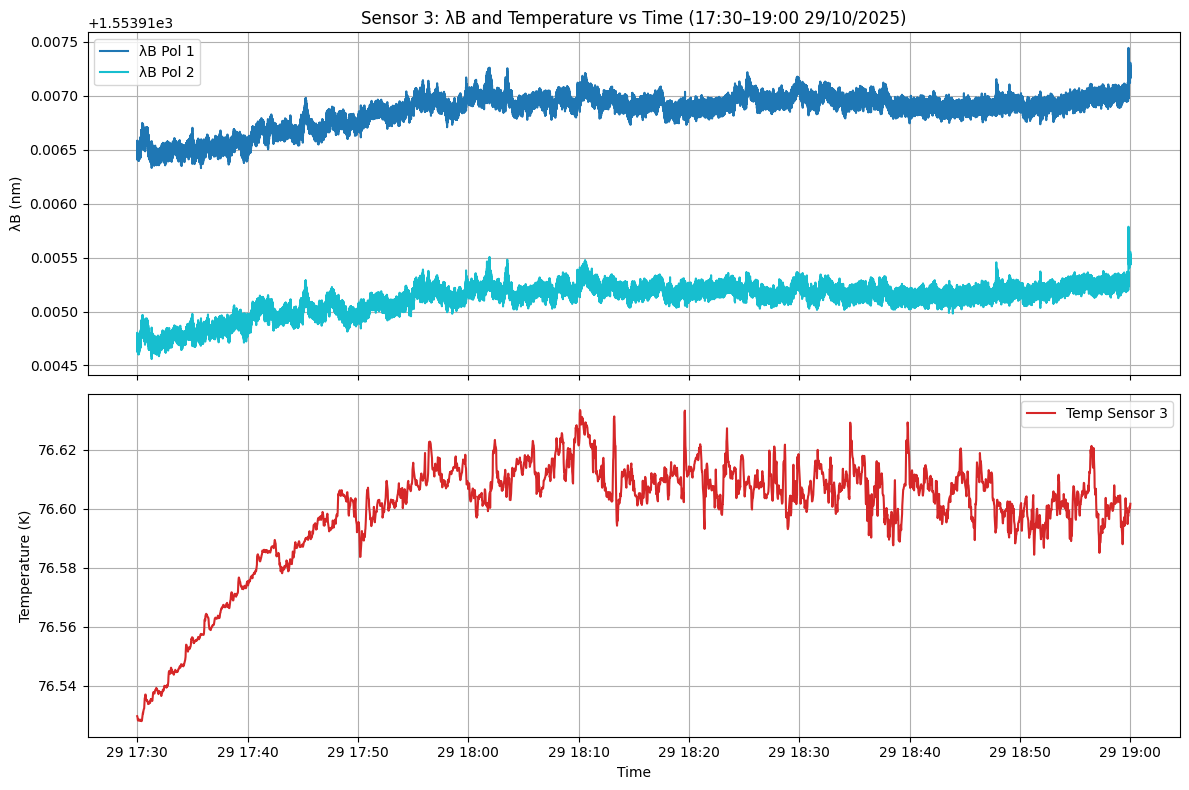

In [4]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Abrir archivo ROOT
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 10, 29, 17, 30, 0)
end_time   = datetime.datetime(2025, 10, 29, 19, 0, 0)

# Aplicar máscara a peak
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

# Aplicar máscara a temp
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Graficar en dos subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Plot λB
ax1.plot(peak_t_filtered, sensor3_pol1_filtered*1e9, label="λB Pol 1", color="tab:blue")
ax1.plot(peak_t_filtered, sensor3_pol2_filtered*1e9, label="λB Pol 2", color="tab:cyan")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (17:30–19:00 29/10/2025)")
ax1.legend()
ax1.grid(True)

# Plot temperatura
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_452/2223745718.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_452/2223745718.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


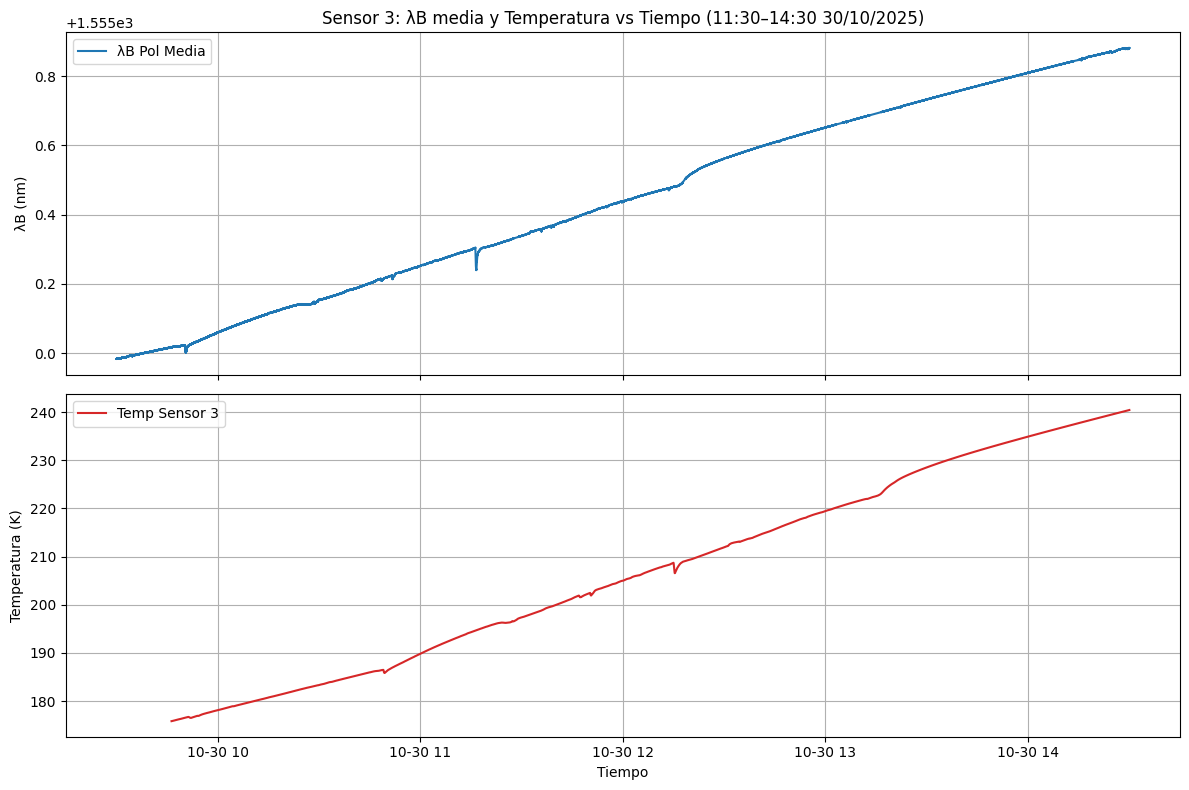

In [5]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# Abrir archivo ROOT
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # primera polarización
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convertir tiempos a datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Definir filtro temporal ---
start_time = datetime.datetime(2025, 10, 30, 9, 30, 0)
end_time   = datetime.datetime(2025, 10, 30, 14, 30, 0)

# Aplicar máscara a peak
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

# Aplicar máscara a temp
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Calcular polarización media ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Graficar en dos subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Plot λB promedio
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="λB Pol Media", color="tab:blue")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB media y Temperatura vs Tiempo (11:30–14:30 30/10/2025)")
ax1.legend()
ax1.grid(True)

# Plot temperatura
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temp Sensor 3", color="tab:red")
ax2.set_xlabel("Tiempo")
ax2.set_ylabel("Temperatura (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_452/2612517230.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_452/2612517230.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])
/cvmfs/sft.cern.ch/lcg/views/LCG_108_swan/x86_64-el9-gcc13-opt/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


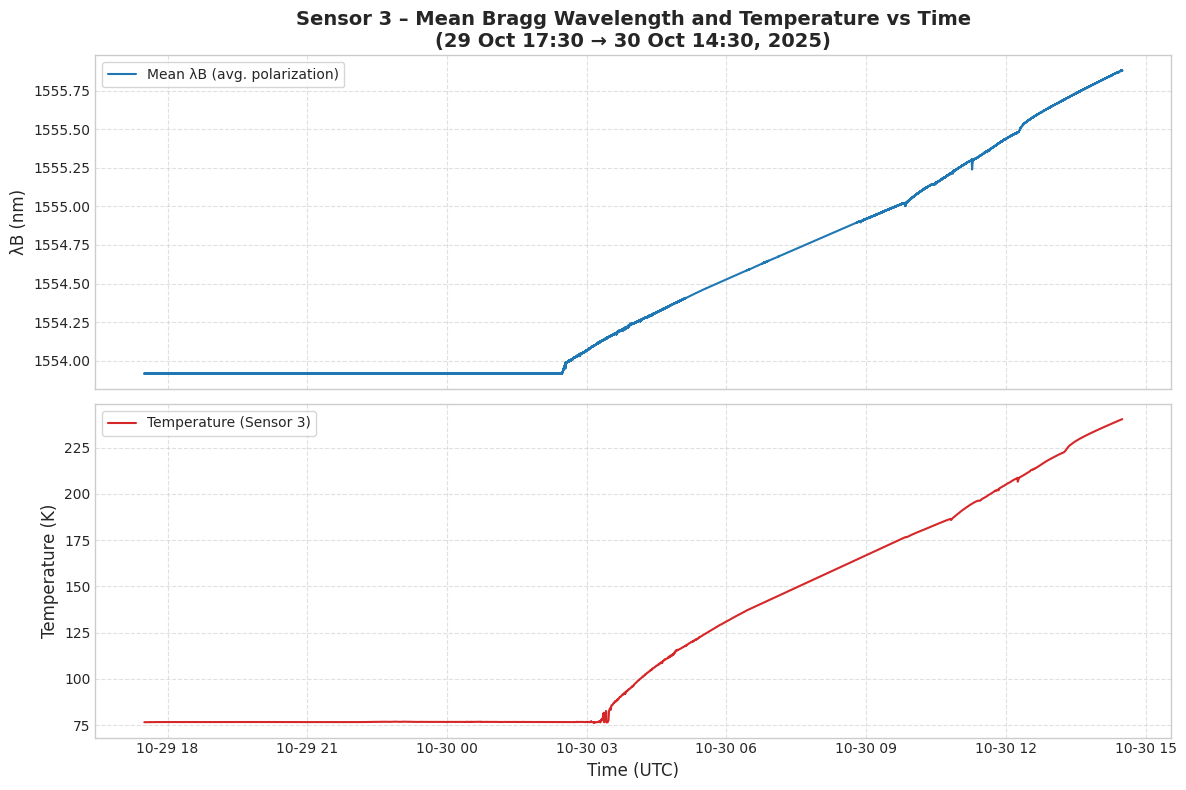

In [8]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Define time window ---
start_time = datetime.datetime(2025, 10, 29, 17, 30, 0)
end_time   = datetime.datetime(2025, 10, 30, 14, 30, 0)

# --- Apply time masks ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average Bragg wavelength (λB) between polarizations ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot: λB and Temperature vs Time ---
plt.style.use("seaborn-v0_8-whitegrid")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# --- λB average ---
ax1.plot(peak_t_filtered, sensor3_mean * 1e9, label="Mean λB (avg. polarization)", color="tab:blue", linewidth=1.5)
ax1.set_ylabel("λB (nm)", fontsize=12)
ax1.set_title("Sensor 3 – Mean Bragg Wavelength and Temperature vs Time\n(29 Oct 17:30 → 30 Oct 14:30, 2025)", fontsize=14, weight='bold')
ax1.legend(frameon=True)
ax1.grid(True, linestyle="--", alpha=0.6)

# --- Temperature ---
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Temperature (Sensor 3)", color="tab:red", linewidth=1.5)
ax2.set_xlabel("Time (UTC)", fontsize=12)
ax2.set_ylabel("Temperature (K)", fontsize=12)
ax2.legend(frameon=True)
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


/tmp/ipykernel_562/3619303488.py:25: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_562/3619303488.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])


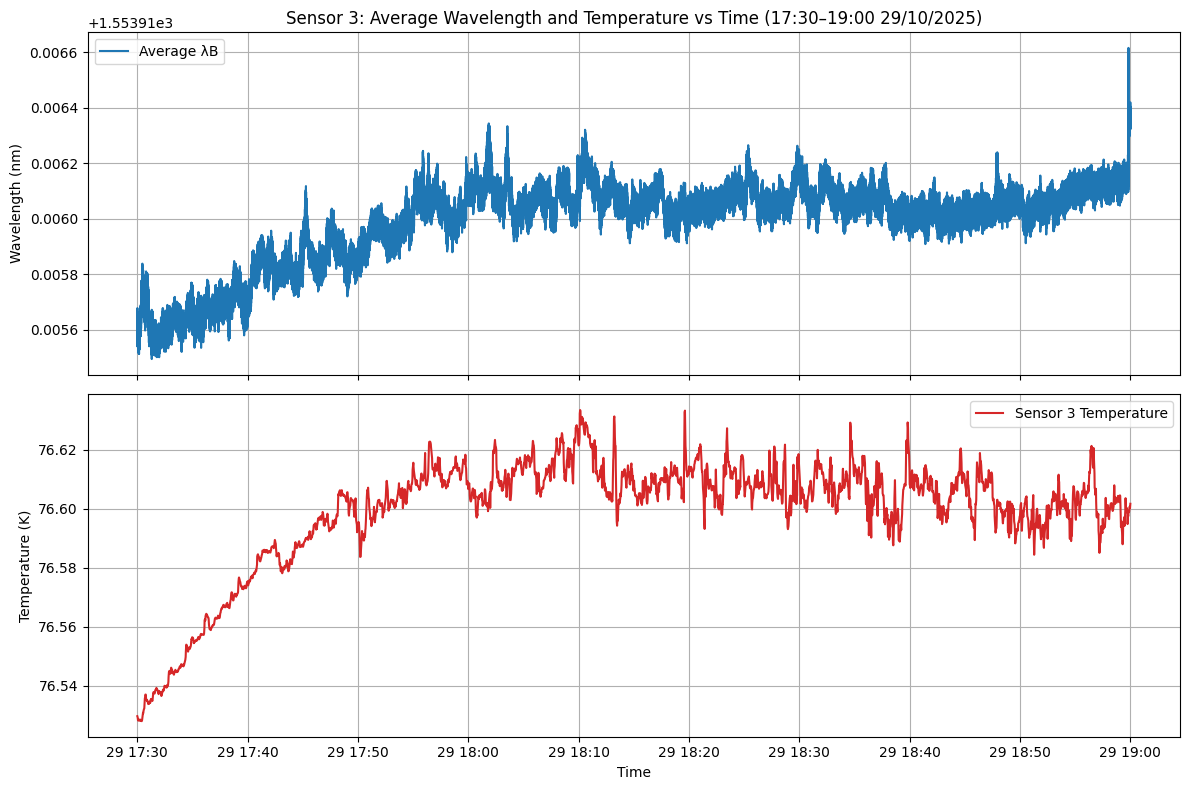

In [19]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]           # first polarization timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]    # polarization 1
sensor3_pol2 = peak_data["wav"][:, 1, 2]    # polarization 2

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime objects ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Define time filter ---
start_time = datetime.datetime(2025, 10, 29, 17, 30, 0)
end_time   = datetime.datetime(2025, 10, 29, 19, 0, 0)

# Apply mask to peak data
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
peak_t_filtered = peak_timestamps[mask_peak]
sensor3_pol1_filtered = sensor3_pol1[mask_peak]
sensor3_pol2_filtered = sensor3_pol2[mask_peak]

# Apply mask to temperature data
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
temp_t_filtered = temp_timestamps[mask_temp]
sensor3_temp_filtered = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_filtered + sensor3_pol2_filtered) / 2

# --- Plot in two subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top subplot: wavelength (λB)
ax1.plot(peak_t_filtered, sensor3_mean*1e9, label="Average λB", color="tab:blue")
ax1.set_ylabel("Wavelength (nm)")
ax1.set_title("Sensor 3: Average Wavelength and Temperature vs Time (17:30–19:00 29/10/2025)")
ax1.legend()
ax1.grid(True)

# Bottom subplot: temperature
ax2.plot(temp_t_filtered, sensor3_temp_filtered, label="Sensor 3 Temperature", color="tab:red")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


/tmp/ipykernel_562/2575480169.py:26: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
/tmp/ipykernel_562/2575480169.py:27: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])
/tmp/ipykernel_562/2575480169.py:64: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  peak_resampled_mean = df_peak.resample("5T").mean()
/tmp/ipykernel_562/2575480169.py:65: FutureWarning: 'T' is deprecated and will be remov

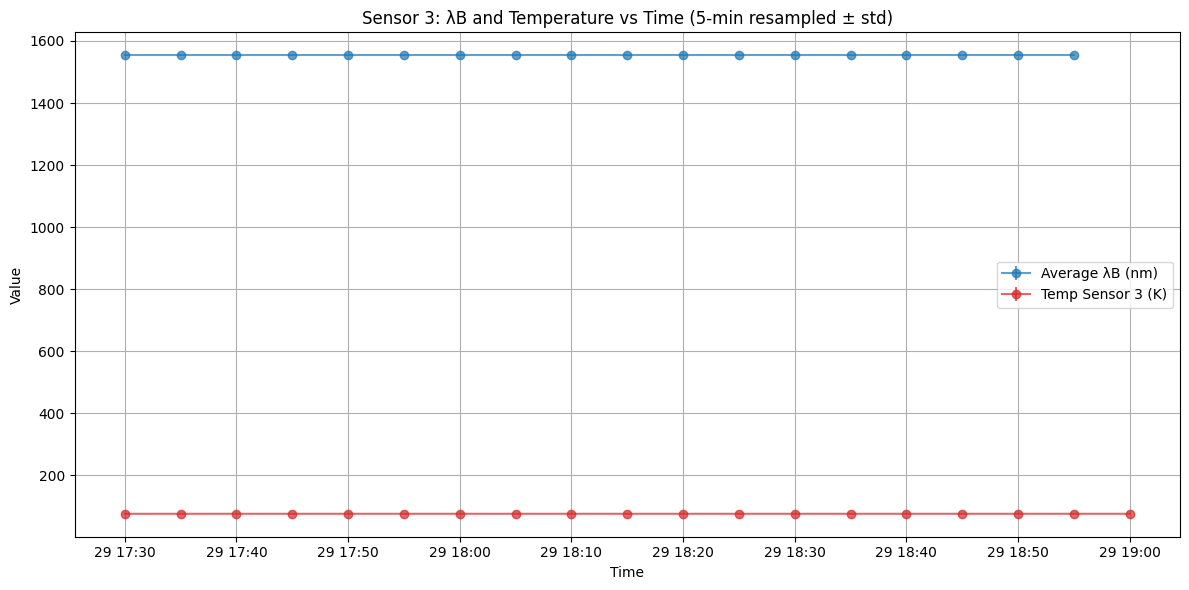

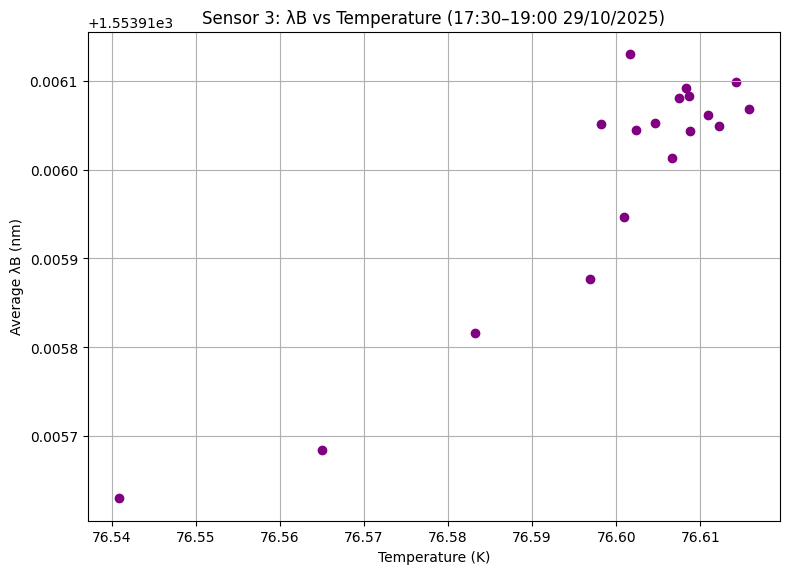

In [20]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"

with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor 3 ---
peak_times = peak_data["t"][:, 0]
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Convert timestamps to datetime ---
peak_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in peak_times])
temp_timestamps = np.array([datetime.datetime.utcfromtimestamp(t) for t in temp_times])

# --- Define time filter ---
start_time = datetime.datetime(2025, 10, 29, 17, 30, 0)
end_time   = datetime.datetime(2025, 10, 29, 19, 0, 0)

# --- Apply mask ---
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

# Filtered data
peak_times_f = peak_timestamps[mask_peak]
sensor3_pol1_f = sensor3_pol1[mask_peak]
sensor3_pol2_f = sensor3_pol2[mask_peak]

temp_times_f = temp_timestamps[mask_temp]
sensor3_temp_f = sensor3_temp[mask_temp]

# --- Compute average polarization ---
sensor3_mean = (sensor3_pol1_f + sensor3_pol2_f) / 2

# --- Convert to DataFrames for resampling ---
df_peak = pd.DataFrame({
    "time": peak_times_f,
    "lambdaB_nm": sensor3_mean * 1e9,
    "lambdaB_pol1_nm": sensor3_pol1_f * 1e9,
    "lambdaB_pol2_nm": sensor3_pol2_f * 1e9
})
df_peak.set_index("time", inplace=True)

df_temp = pd.DataFrame({
    "time": temp_times_f,
    "temp_K": sensor3_temp_f
})
df_temp.set_index("time", inplace=True)

# --- Resample every 5 minutes, computing mean and std ---
peak_resampled_mean = df_peak.resample("5T").mean()
peak_resampled_std  = df_peak.resample("5T").std()

temp_resampled_mean = df_temp.resample("5T").mean()
temp_resampled_std  = df_temp.resample("5T").std()

# --- Plot λB and Temperature vs Time with error bars ---
fig, ax = plt.subplots(figsize=(12,6))

# λB with std
ax.errorbar(peak_resampled_mean.index, peak_resampled_mean["lambdaB_nm"],
            yerr=peak_resampled_std["lambdaB_nm"], label="Average λB (nm)",
            color="tab:blue", fmt='-o', alpha=0.7)

# Temperature with std
ax.errorbar(temp_resampled_mean.index, temp_resampled_mean["temp_K"],
            yerr=temp_resampled_std["temp_K"], label="Temp Sensor 3 (K)",
            color="tab:red", fmt='-o', alpha=0.7)

ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.set_title("Sensor 3: λB and Temperature vs Time (5-min resampled ± std)")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

# --- Scatter λB vs Temperature ---
df_combined = pd.merge_asof(peak_resampled_mean.reset_index(),
                            temp_resampled_mean.reset_index(),
                            left_on="time", right_on="time")

plt.figure(figsize=(8,6))
plt.scatter(df_combined["temp_K"], df_combined["lambdaB_nm"], color="purple")
plt.xlabel("Temperature (K)")
plt.ylabel("Average λB (nm)")
plt.title("Sensor 3: λB vs Temperature (17:30–19:00 29/10/2025)")
plt.grid(True)
plt.tight_layout()
plt.show()


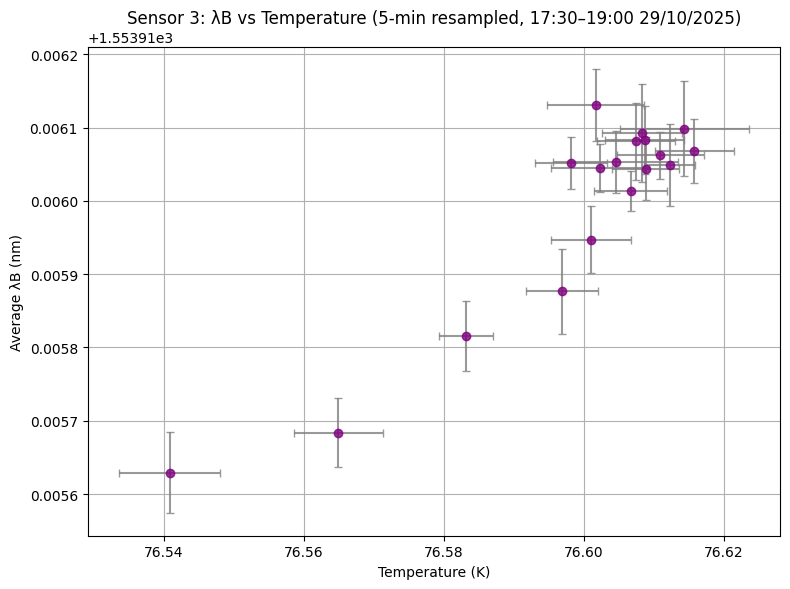

In [23]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Extract Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # take first polarization for timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Average the two polarizations ---
sensor3_lambdaB = (sensor3_pol1 + sensor3_pol2) / 2

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- Filter time range: 17:30 - 19:00 on 29-Oct-2025 ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 19, 0)

# Apply time masks
mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor3_lambdaB[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor3_temp[mask_temp]

# --- Build DataFrames ---
df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)

# --- Resample every 5 minutes, compute mean and std ---
peak_resampled = df_peak.resample("5min").agg(["mean","std"])
temp_resampled = df_temp.resample("5min").agg(["mean","std"])

# --- Combine into single DataFrame aligned by time ---
df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()

# --- Scatter plot λB vs Temperature with error bars ---
plt.figure(figsize=(8,6))
plt.errorbar(
    df_combined["temp_K"]["mean"], 
    df_combined["lambdaB_nm"]["mean"], 
    xerr=df_combined["temp_K"]["std"], 
    yerr=df_combined["lambdaB_nm"]["std"], 
    fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
)
plt.xlabel("Temperature (K)")
plt.ylabel("Average λB (nm)")
plt.title("Sensor 3: λB vs Temperature (5-min resampled, 17:30–19:00 29/10/2025)")
plt.grid(True)
plt.tight_layout()
plt.show()


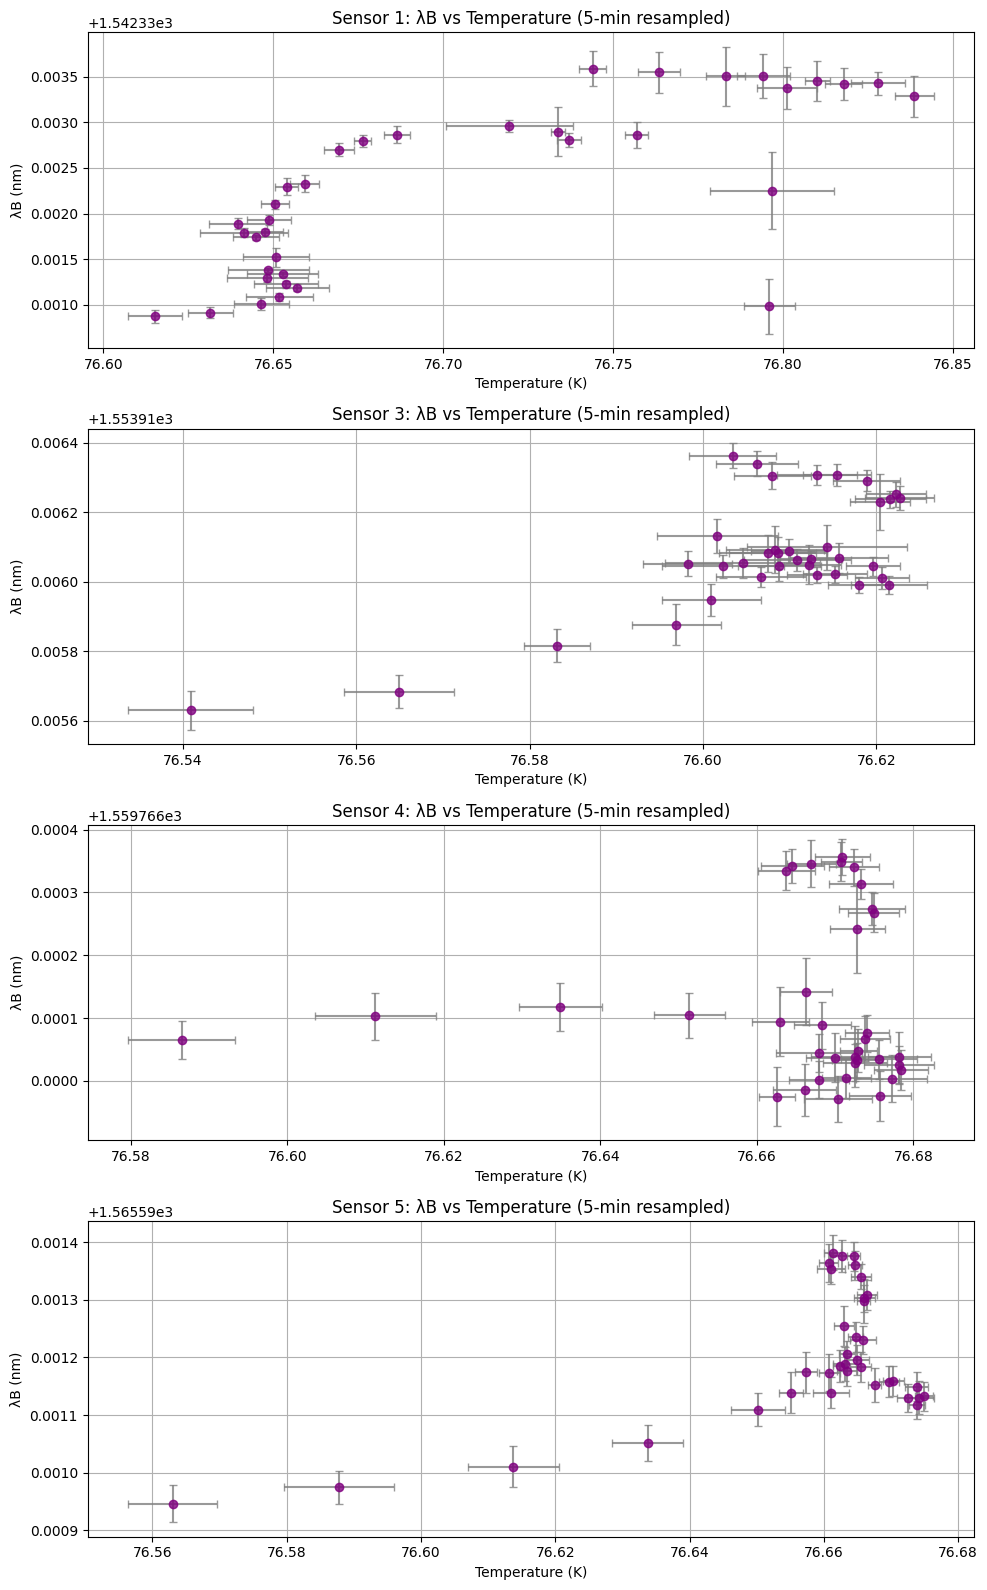

In [31]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Filter time window ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 20, 30)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(10, 16), sharex=False)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # Combine resampled data
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Scatter plot λB vs Temperature with error bars ---
    axes[i].errorbar(
        df_combined["temp_K"]["mean"], 
        df_combined["lambdaB_nm"]["mean"], 
        xerr=df_combined["temp_K"]["std"], 
        yerr=df_combined["lambdaB_nm"]["std"], 
        fmt='o', color='purple', ecolor='gray', capsize=3, alpha=0.8
    )
    axes[i].set_xlabel("Temperature (K)")
    axes[i].set_ylabel("λB (nm)")
    axes[i].set_title(f"Sensor {sensor+1}: λB vs Temperature (5-min resampled)")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


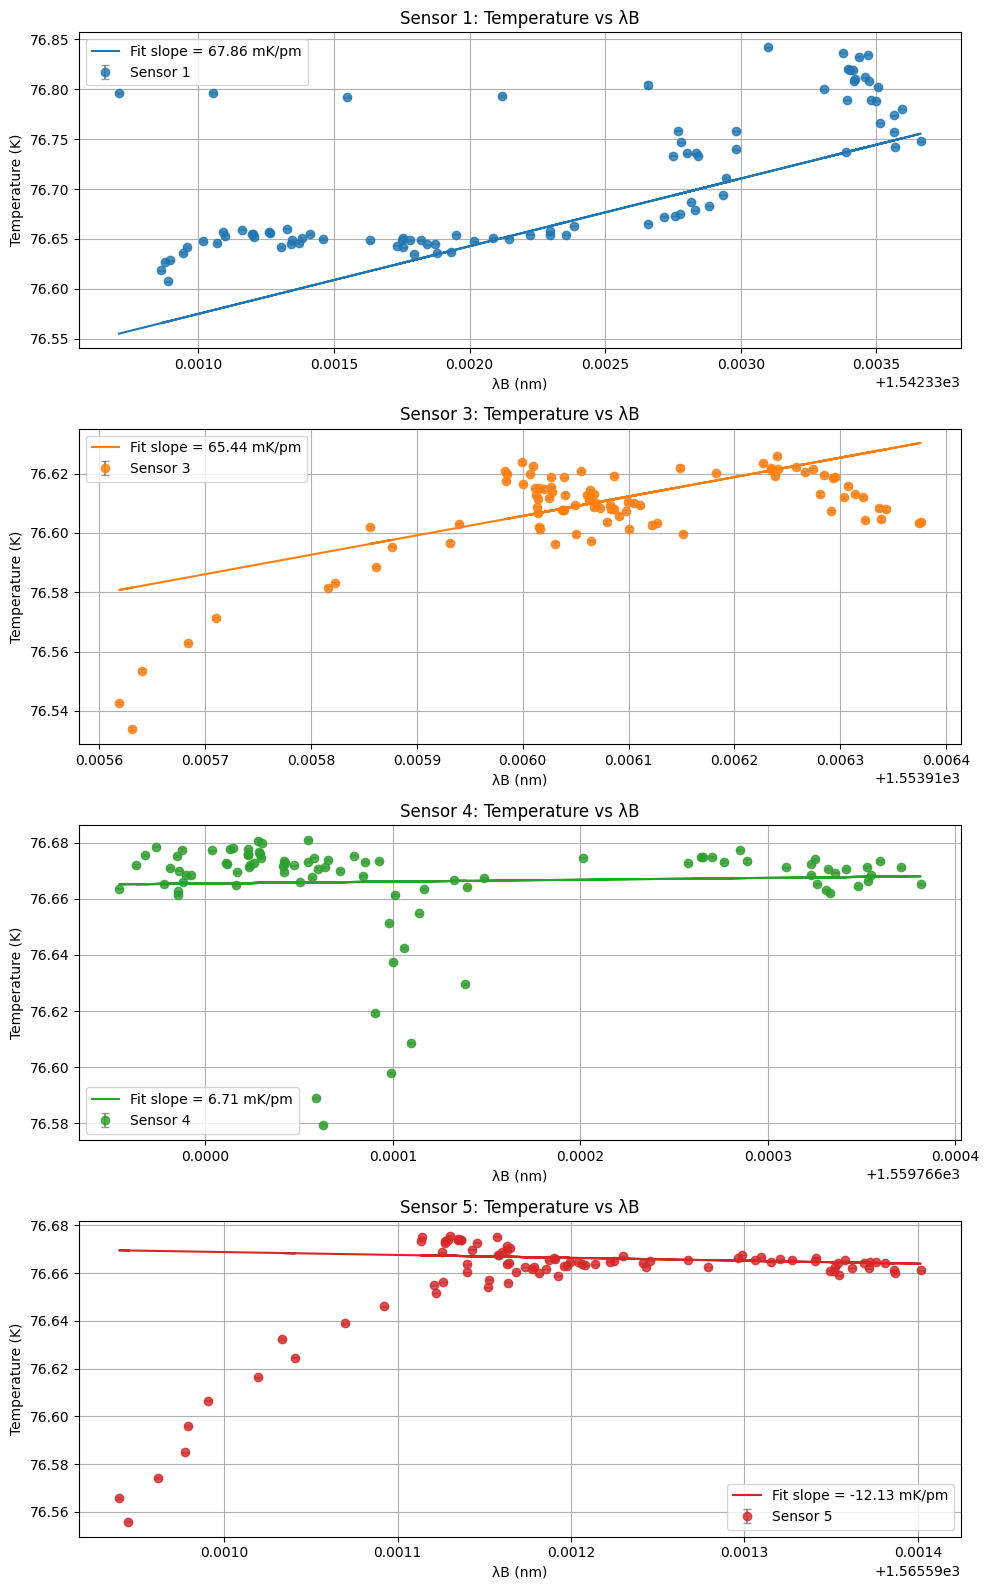

In [20]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Abrir archivo ROOT ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensores a analizar (1,3,4,5) ---
sensors = [0, 2, 3, 4]

# --- Convertir timestamps ---
peak_times = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_times = pd.to_datetime(temp_data["t"], unit='s')

# --- Filtrar ventana temporal ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 20, 30)
mask_peak = (peak_times >= start_time) & (peak_times <= end_time)
mask_temp = (temp_times >= start_time) & (temp_times <= end_time)
peak_t_filtered = peak_times[mask_peak]
temp_t_filtered = temp_times[mask_temp]

# --- Colores fijos para cada sensor ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]

# --- Crear figura ---
fig, axes = plt.subplots(len(sensors), 1, figsize=(10, 16))

for i, sensor in enumerate(sensors):
    # λB promedio de las dos polarizaciones
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]  # en metros
    
    # Temperatura
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)  # nm
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)              # K
    
    # Resample a 2 minutos y calcular media y std
    peak_resampled = df_peak.resample("2min").agg(['mean','std'])
    temp_resampled = df_temp.resample("2min").agg(['mean','std'])
    
    # SEM
    peak_resampled['lambdaB_nm','se'] = peak_resampled['lambdaB_nm','std'] / np.sqrt(df_peak.resample("2min").count()['lambdaB_nm'])
    temp_resampled['temp_K','se'] = temp_resampled['temp_K','std'] / np.sqrt(df_temp.resample("2min").count()['temp_K'])
    
    # Unir resampled y eliminar NaN
    df_combined = pd.concat([peak_resampled, temp_resampled], axis=1).dropna()
    
    # --- Ajuste lineal en unidades originales: x=nm, y=K ---
    x = df_combined['lambdaB_nm','mean'].values
    y = df_combined['temp_K','mean'].values
    yerr = df_combined['temp_K','se'].values
    
    # Ajuste lineal ponderado por error en y
    w = 1 / yerr**2
    slope, intercept = np.polyfit(x, y, 1, w=w)
    
    # Transformar pendiente a mK/pm para reportarla
    slope_mK_pm = slope * (1e3 / 1e3)  # K/nm -> mK/pm (numéricamente igual)
    
    # Scatter con barras de error y línea de fit
    axes[i].errorbar(x, y, yerr=yerr, fmt='o', color=colors[i], ecolor='gray', capsize=3, alpha=0.8, label=f"Sensor {sensor+1}")
    axes[i].plot(x, slope*x + intercept, '-', color=colors[i], label=f"Fit slope = {slope_mK_pm:.2f} mK/pm")
    
    axes[i].set_xlabel("λB (nm)")
    axes[i].set_ylabel("Temperature (K)")
    axes[i].set_title(f"Sensor {sensor+1}: Temperature vs λB")
    axes[i].grid(True)
    axes[i].legend()

plt.tight_layout()
plt.show()


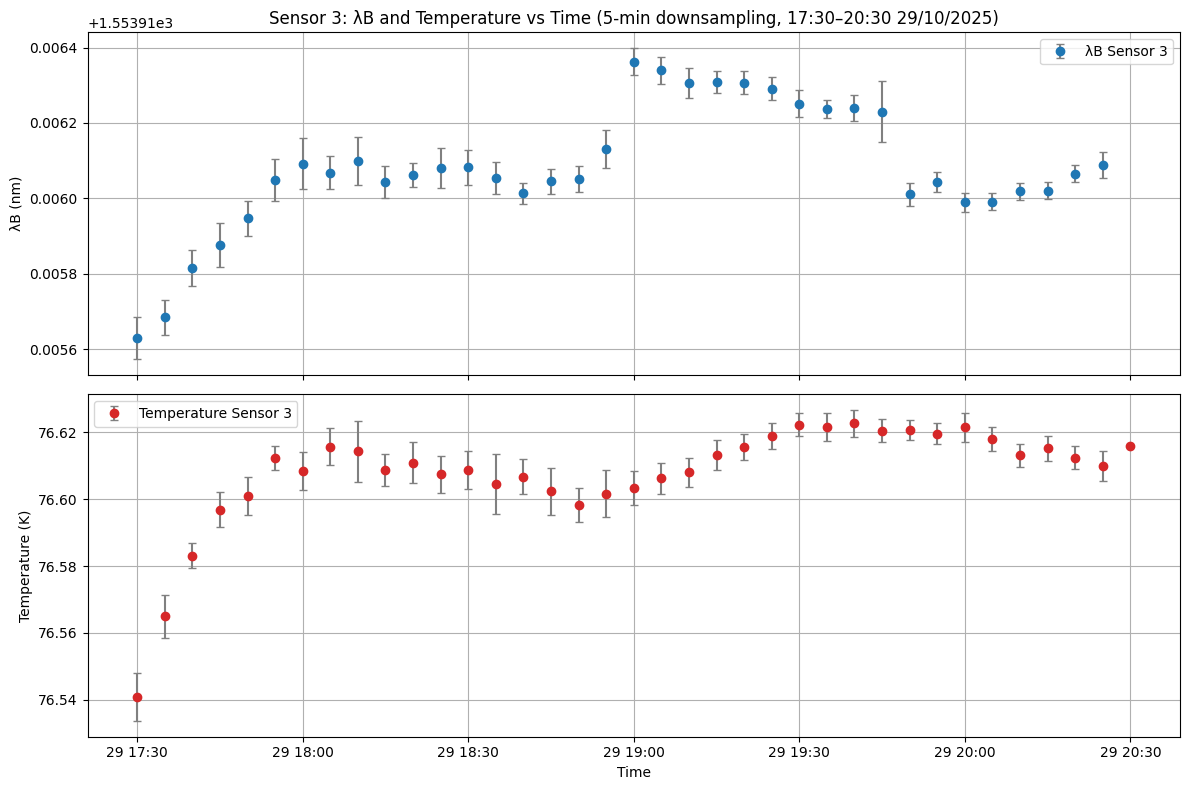

In [27]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Extract Sensor 3 data ---
peak_times = peak_data["t"][:, 0]           # first polarization timestamps
sensor3_pol1 = peak_data["wav"][:, 0, 2]
sensor3_pol2 = peak_data["wav"][:, 1, 2]

temp_times = temp_data["t"]
sensor3_temp = temp_data["temp"][:, 2]

# --- Average the two polarizations ---
sensor3_lambdaB = (sensor3_pol1 + sensor3_pol2) / 2

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- Filter time window: 17:30 - 19:00 29/10/2025 ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 20, 30)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor3_lambdaB[mask_peak]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor3_temp[mask_temp]

# --- Create DataFrames ---
df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)

# --- Resample every 5 minutes, calculate mean and std ---
peak_resampled = df_peak.resample("5min").agg(["mean","std"])
temp_resampled = df_temp.resample("5min").agg(["mean","std"])

# --- Plot in two subplots ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,8), sharex=True)

# Top subplot: λB vs time with error bars
ax1.errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
             yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color="tab:blue",
             ecolor='gray', capsize=3, label="λB Sensor 3")
ax1.set_ylabel("λB (nm)")
ax1.set_title("Sensor 3: λB and Temperature vs Time (5-min downsampling, 17:30–20:30 29/10/2025)")
ax1.grid(True)
ax1.legend()

# Bottom subplot: Temperature vs time with error bars
ax2.errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
             yerr=temp_resampled["temp_K"]["std"], fmt='o', color="tab:red",
             ecolor='gray', capsize=3, label="Temperature Sensor 3")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature (K)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()


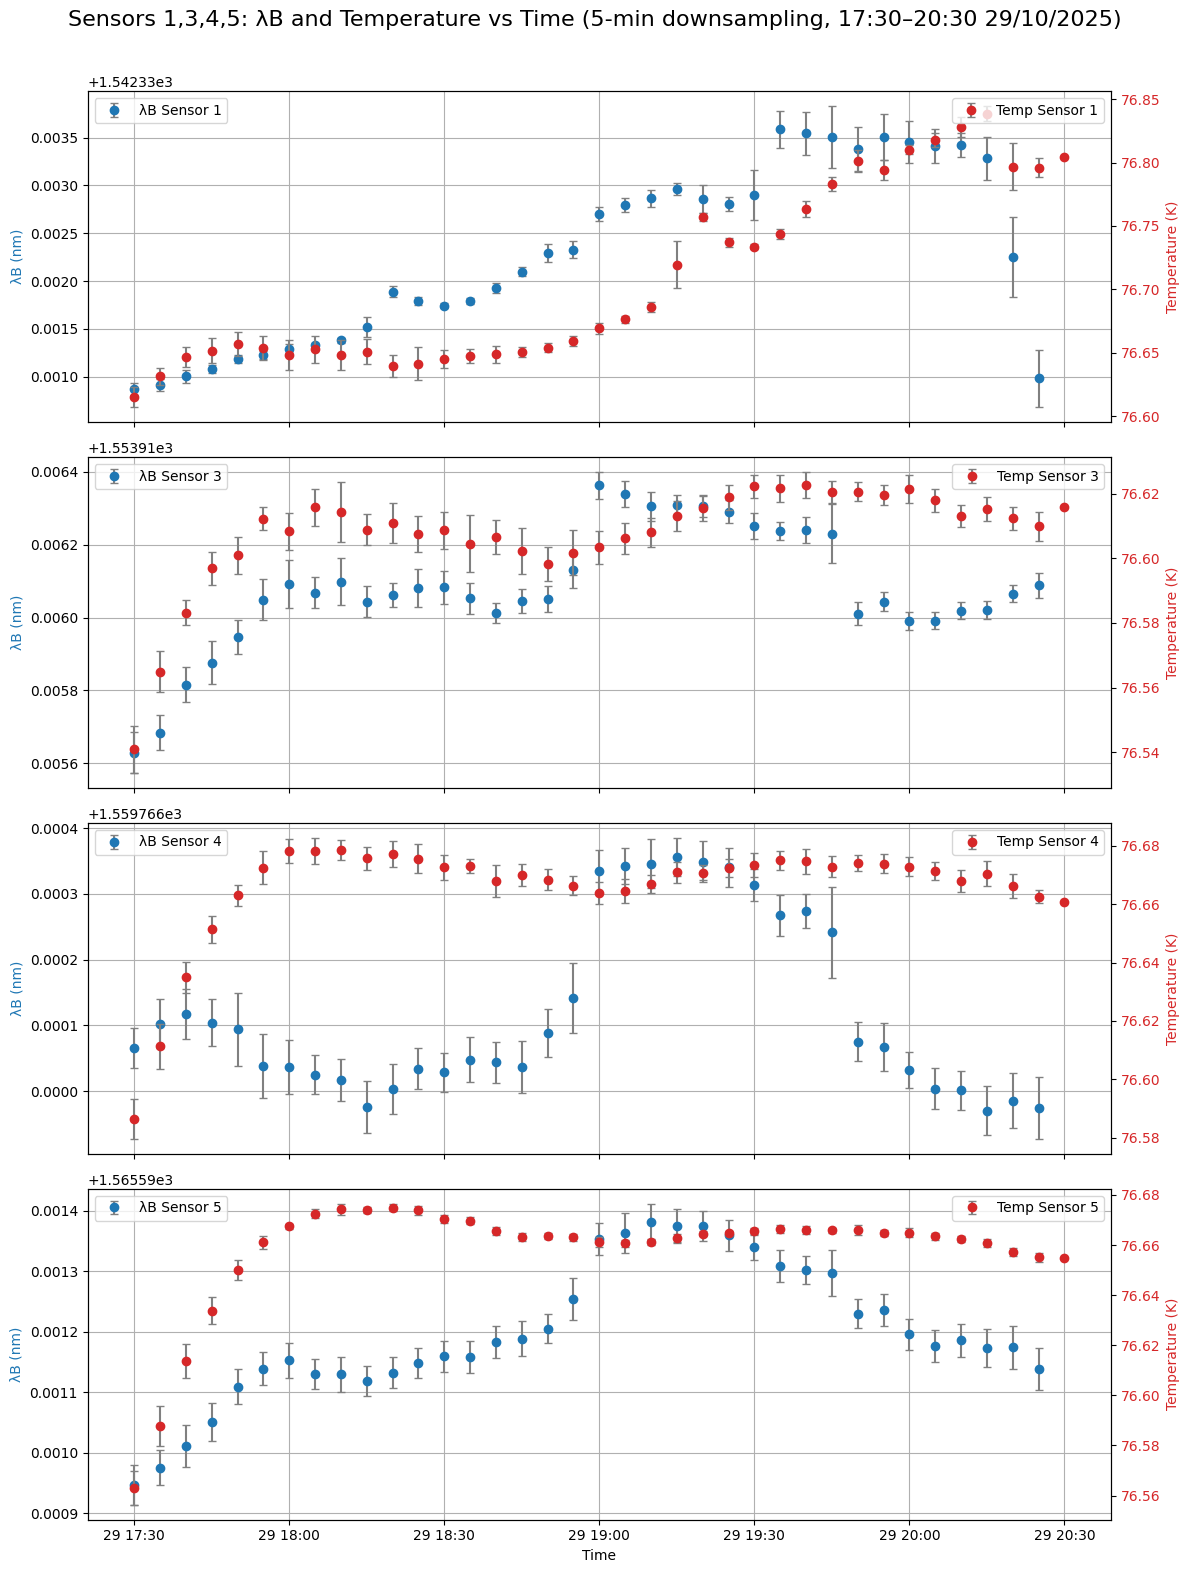

In [32]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot ---
sensors = [0, 2, 3, 4]  # positions: 1,3,4,5

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Filter time window ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 20, 30)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
temp_t_filtered = temp_timestamps[mask_temp]

# --- Create figure with 4 subplots ---
fig, axes = plt.subplots(4, 1, figsize=(12, 16), sharex=True)

for i, sensor in enumerate(sensors):
    # λB average of two polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor] + peak_data["wav"][:, 1, sensor]) / 2
    lambdaB_filtered = lambdaB[mask_peak]
    
    # Temperature
    temp_sensor = temp_data["temp"][:, sensor]
    temp_filtered = temp_sensor[mask_temp]
    
    # Create DataFrames
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB_filtered * 1e9}, index=peak_t_filtered)
    df_temp = pd.DataFrame({"temp_K": temp_filtered}, index=temp_t_filtered)
    
    # Resample every 5 minutes and calculate mean & std
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])
    
    # --- Plot λB with error bars ---
    axes[i].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                     yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color="tab:blue",
                     ecolor='gray', capsize=3, label=f"λB Sensor {sensor+1}")
    axes[i].set_ylabel("λB (nm)", color="tab:blue")
    axes[i].grid(True)
    axes[i].legend(loc="upper left")
    
    # --- Plot Temperature with error bars on secondary y-axis ---
    ax2 = axes[i].twinx()
    ax2.errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                 yerr=temp_resampled["temp_K"]["std"], fmt='o', color="tab:red",
                 ecolor='gray', capsize=3, label=f"Temp Sensor {sensor+1}")
    ax2.set_ylabel("Temperature (K)", color="tab:red")
    ax2.tick_params(axis='y', labelcolor="tab:red")
    ax2.legend(loc="upper right")

axes[-1].set_xlabel("Time")
plt.suptitle("Sensors 1,3,4,5: λB and Temperature vs Time (5-min downsampling, 17:30–20:30 29/10/2025)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


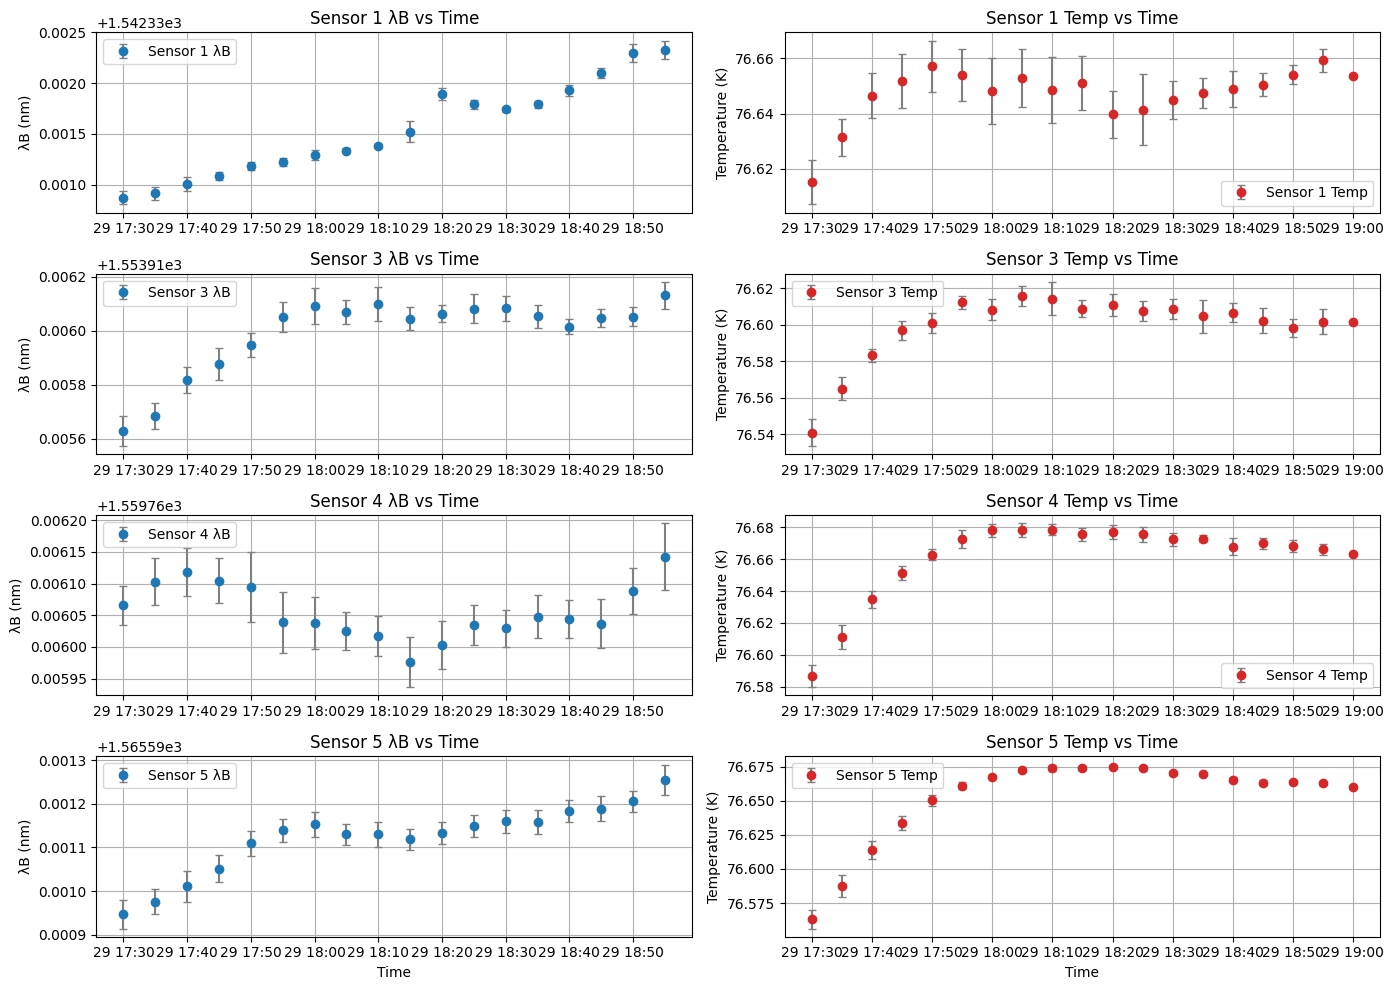

In [33]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices to plot (0-based, skipping sensor 2) ---
sensor_indices = [0, 2, 3, 4]  # sensors 1,3,4,5

# --- Convert times to datetime ---
peak_timestamps = pd.to_datetime(peak_data["t"][:, 0], unit='s')
temp_timestamps = pd.to_datetime(temp_data["t"], unit='s')

# --- Time window ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 19, 0)

# --- Create figure ---
fig, axes = plt.subplots(len(sensor_indices), 2, figsize=(14, 10), sharex=False)
fig.subplots_adjust(hspace=0.4)

for i, sensor_idx in enumerate(sensor_indices):
    # Extract λB and average over polarizations
    lambdaB = (peak_data["wav"][:, 0, sensor_idx] + peak_data["wav"][:, 1, sensor_idx]) / 2
    mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
    df_peak = pd.DataFrame({"lambdaB_nm": lambdaB[mask_peak]*1e9}, index=peak_timestamps[mask_peak])
    peak_resampled = df_peak.resample("5min").agg(["mean","std"])

    # Extract temperature
    sensor_temp = temp_data["temp"][:, sensor_idx]
    mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)
    df_temp = pd.DataFrame({"temp_K": sensor_temp[mask_temp]}, index=temp_timestamps[mask_temp])
    temp_resampled = df_temp.resample("5min").agg(["mean","std"])

    # --- Plot λB vs Time ---
    axes[i, 0].errorbar(peak_resampled.index, peak_resampled["lambdaB_nm"]["mean"],
                        yerr=peak_resampled["lambdaB_nm"]["std"], fmt='o', color='tab:blue',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} λB")
    axes[i, 0].set_ylabel("λB (nm)")
    axes[i, 0].set_title(f"Sensor {sensor_idx+1} λB vs Time")
    axes[i, 0].grid(True)
    axes[i, 0].legend()

    # --- Plot Temp vs Time ---
    axes[i, 1].errorbar(temp_resampled.index, temp_resampled["temp_K"]["mean"],
                        yerr=temp_resampled["temp_K"]["std"], fmt='o', color='tab:red',
                        ecolor='gray', capsize=3, label=f"Sensor {sensor_idx+1} Temp")
    axes[i, 1].set_ylabel("Temperature (K)")
    axes[i, 1].set_title(f"Sensor {sensor_idx+1} Temp vs Time")
    axes[i, 1].grid(True)
    axes[i, 1].legend()

# X-label for bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Time")

plt.tight_layout()
plt.show()


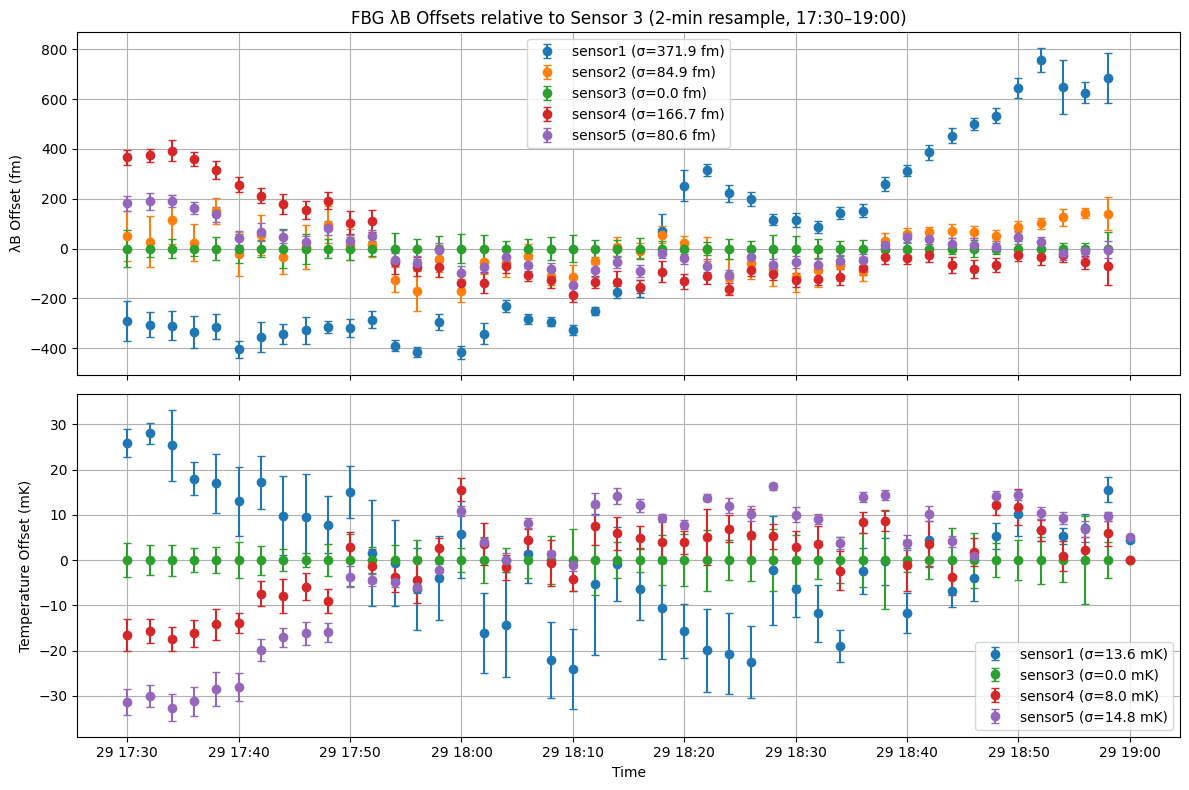

In [7]:
import uproot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

# --- Open ROOT file ---
input_filename = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/Dewar1m/20251029.root"
with uproot.open(input_filename) as file:
    peak_tree = file["peak"]
    temp_tree = file["temp"]
    
    peak_data = peak_tree.arrays(library="np")
    temp_data = temp_tree.arrays(library="np")

# --- Sensor indices ---
sensors_peak = [0, 1, 2, 3, 4]  # Sensor2 incluido
sensors_temp = [0, 2, 3, 4]     # Excluimos Sensor2

# --- Average polarizations ---
peak_times = peak_data["t"][:, 0]
sensor_lambdaB = np.mean(peak_data["wav"][:, :, :], axis=1)  # media sobre polarizaciones

temp_times = temp_data["t"]
sensor_temp = temp_data["temp"]

# --- Convert timestamps to datetime ---
peak_timestamps = pd.to_datetime(peak_times, unit='s')
temp_timestamps = pd.to_datetime(temp_times, unit='s')

# --- Filter time window ---
start_time = datetime.datetime(2025, 10, 29, 17, 30)
end_time   = datetime.datetime(2025, 10, 29, 19, 0)

mask_peak = (peak_timestamps >= start_time) & (peak_timestamps <= end_time)
mask_temp = (temp_timestamps >= start_time) & (temp_timestamps <= end_time)

peak_t_filtered = peak_timestamps[mask_peak]
lambdaB_filtered = sensor_lambdaB[mask_peak, :]

temp_t_filtered = temp_timestamps[mask_temp]
temp_filtered = sensor_temp[mask_temp, :]

# --- Build DataFrames ---
df_peak = pd.DataFrame(lambdaB_filtered * 1e15,  # convertir nm -> fm
                       columns=[f"sensor{i+1}" for i in range(lambdaB_filtered.shape[1])], 
                       index=peak_t_filtered)
df_temp = pd.DataFrame(temp_filtered[:, sensors_temp] * 1e3,  # K -> mK
                       columns=[f"sensor{i+1}" for i in sensors_temp], 
                       index=temp_t_filtered)

# --- Resample cada 2 minutos ---
peak_resampled = df_peak.resample("2min").agg(["mean","std"])
temp_resampled = df_temp.resample("2min").agg(["mean","std"])

# --- Compute offsets relative to Sensor3 (index 2) y centrar ---
lambda_mean = peak_resampled.xs('mean', axis=1, level=1)
lambda_offsets = lambda_mean.subtract(lambda_mean["sensor3"], axis=0)
lambda_offsets_centered = lambda_offsets - lambda_offsets.mean()

temp_mean = temp_resampled.xs('mean', axis=1, level=1)
temp_offsets = temp_mean.subtract(temp_mean["sensor3"], axis=0)
temp_offsets_centered = temp_offsets - temp_offsets.mean()

# --- Extract std for error bars ---
lambda_std = peak_resampled.xs('std', axis=1, level=1)
temp_std = temp_resampled.xs('std', axis=1, level=1)

# --- Compute total std along time for legend ---
lambda_std_total = lambda_offsets_centered.std()
temp_std_total = temp_offsets_centered.std()

# --- Plot ---
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple"]  # Sensor2 extra included for peaks

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8), sharex=True)

# Top subplot: λB offsets (scatter + std)
for i, s in enumerate(lambda_offsets_centered.columns):
    ax1.errorbar(peak_resampled.index, lambda_offsets_centered[s],
                 yerr=lambda_std[s], fmt='o', color=colors[i], capsize=3,
                 label=f"{s} (σ={lambda_std_total[s]:.1f} fm)")
ax1.set_ylabel("λB Offset (fm)")
ax1.set_title("FBG λB Offsets relative to Sensor 3 (2-min resample, 17:30–19:00)")
ax1.grid(True)
ax1.legend()

# Bottom subplot: Temperature offsets (scatter + std, exclude sensor2)
for i, s in enumerate(temp_offsets_centered.columns):
    ax2.errorbar(temp_resampled.index, temp_offsets_centered[s],
                 yerr=temp_std[s], fmt='o', color=colors[i if i<1 else i+1], capsize=3,
                 label=f"{s} (σ={temp_std_total[s]:.1f} mK)")
ax2.set_xlabel("Time")
ax2.set_ylabel("Temperature Offset (mK)")
ax2.grid(True)
ax2.legend()

plt.tight_layout()
plt.show()
